
# Lab 3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?

#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3**

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

In [1]:
import numpy as np
import pandas as pd
import time as tm
import matplotlib.pyplot as plt
import math as mt

Terminos de Fourier necesarios para tol=1e-4: 73


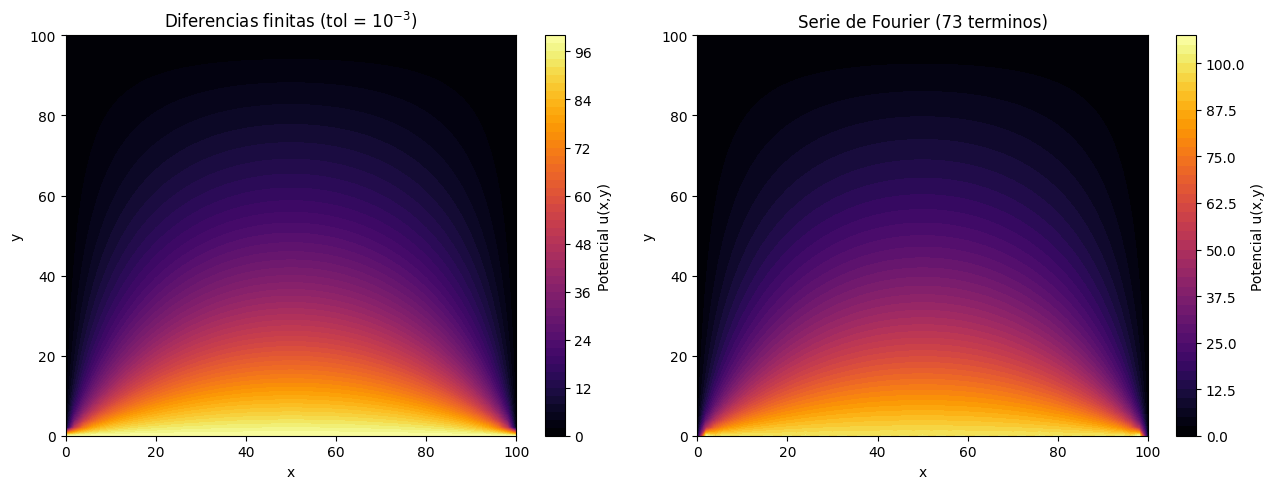

In [6]:
#valores iniciales
grid_size = 100
V0_boundary = 100
Nmax = grid_size
L = 100
Delta = 2
N = int(L / Delta)
V0 = 100
Niter = 20000
tolerancia = 1e-3

#grid of zeros
V_initial = np.zeros((grid_size, grid_size))

#Dirichlet boundary conditions

V_initial[0, :] = V0_boundary
#diferencias finitas
def Laplace2D_FDM(V_ini, Niter, tol):
    V = V_ini.copy()
    for _ in range(Niter):
        V_old = V.copy()
        # Promedio de los 4 nodos vecinos
        V[1:-1, 1:-1] = 0.25 * (V[2:, 1:-1] + V[:-2, 1:-1] + V[1:-1, 2:] + V[1:-1, :-2])

        # Criterio de parada basado en la tolerancia
        if np.max(np.abs(V - V_old)) < tol:
            break

    return V

#Fourier
def Laplace2D_Fourier(X, Y, L, V0, terms):
    V_analitico = np.zeros_like(X)
    for n in range(1, terms*2, 2):
        term_x = np.sin(n * np.pi * X / L)
        term_y = np.sinh(n * np.pi * (L - Y) / L) / np.sinh(n * np.pi)
        V_analitico += (4 * V0 / (n * np.pi)) * term_x * term_y
    return V_analitico

#1. solucion de diferencias finitas:

V_ini = np.zeros((N + 1, N + 1))
V_ini[0, :] = V0
V_fdm = Laplace2D_FDM(V_ini, Niter, tol=tolerancia)

# 2. Cálculo de términos en Fourier para tol = 10^-4 y la matriz
terminos = 1
V_ant = np.zeros_like(X)
while True:
    V_act = Laplace2D_Fourier(X, Y, L, V0, terminos)
    # Evaluamos la tolerancia excluyendo la frontera inferior (y=0) donde la serie diverge
    max_diff = np.max(np.abs(V_act[1:, :] - V_ant[1:, :]))
    if max_diff < 1e-4 and terminos > 1:
        print(f"Terminos de Fourier necesarios para tol=1e-4: {terminos}")
        V_fourier = V_act
        break
    V_ant = V_act.copy()
    terminos += 1


#dominio para graficar
x = np.linspace(0, L, N+1)
y = np.linspace(0, L, N+1)

#superficie
X, Y = np.meshgrid(x, y)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))

# Gráfica 1: Diferencias finitas
c1 = axs[0].contourf(X, Y, V_fdm, 50, cmap='inferno')
axs[0].set_title('Diferencias finitas (tol = $10^{-3}$)')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
fig.colorbar(c1, ax=axs[0], label='Potencial u(x,y)')

# Gráfica 2: Serie de Fourier
c2 = axs[1].contourf(X, Y, V_fourier, 50, cmap='inferno')
axs[1].set_title(f'Serie de Fourier ({terminos} terminos)')
axs[1].set_xlabel('x')
axs[1].set_ylabel('y')
fig.colorbar(c2, ax=axs[1], label='Potencial u(x,y)')

plt.tight_layout()
plt.show()


## Estrategia para resolver la Ecuación de Laplace con Diferencias Finitas (Método de Jacobi con Tolerancia)

La estrategia utilizada para resolver la Ecuación de Laplace se basa en el **Método de Jacobi** para diferencias finitas, pero con una condición de parada basada en la **tolerancia** en lugar de un número fijo de iteraciones.

### 1. Inicialización de la Malla
Primero, se define una malla bidimensional (`initial_potential_grid`) de tamaño `grid_size` x `grid_size`, donde cada punto representa un valor de potencial. Esta malla se inicializa con ceros.

### 2. Aplicación de las Condiciones de Contorno de Dirichlet
Se aplican las condiciones de contorno de Dirichlet, que especifican los valores del potencial en los bordes de la región. Para este ejercicio:
- El borde inferior (`u(x,0)`) se establece a un potencial `V0_boundary` (100V).
- Los demás bordes (`u(0,y)`, `u(L,y)`, `u(x,L)`) se mantienen a 0V.

### 3. Iteración del Método de Jacobi
La función `Laplace2D_FDM` implementa el método de Jacobi. En cada paso de iteración:
- Se recorren todos los puntos **internos** de la malla (excluyendo los bordes, ya que sus valores son fijos por las condiciones de contorno).
- Para cada punto interno `V[i,j]`, su nuevo valor se calcula como el promedio de sus cuatro vecinos adyacentes (`V[i+1,j]`, `V[i-1,j]`, `V[i,j+1]`, `V[i,j-1]`). Esta es la formulación de diferencias finitas de la ecuación de Laplace $\nabla^2 u = 0$.

### 4. Condición de Parada por Tolerancia
En lugar de un número fijo de iteraciones, el algoritmo continúa iterando hasta que la **máxima diferencia** entre los valores de potencial de la iteración actual y la anterior sea menor que una `tolerancia` predefinida (en este caso, $10^{-3}$). Esto asegura que el sistema ha alcanzado un estado de "equilibrio" o "convergencia" dentro de un margen de error aceptable. Si esta condición no se cumple después de un `Niter` (20000) preestablecidas, el bucle también se detiene para evitar cómputos excesivos. La 'max_change' se calcula en cada iteración y se compara con la tolerancia.

### 5. Actualización del Campo de Potencial
Es crucial notar que, para el método de Jacobi, los valores de los vecinos utilizados para calcular un nuevo punto deben ser los de la iteración *anterior*. Por lo tanto, se utiliza una copia (`V = V_ini.copy`) para almacenar los valores actualizados de la iteración actual, y solo al finalizar el recorrido de todos los puntos internos, `V` se actualiza con `V = V_ini.copy` para la siguiente iteración.

### 6. Resultado
La función devuelve la matriz `V` final (el campo de potencial `u(x,y)` resuelto) y el número total de iteraciones necesarias para converger, lo que permite observar la eficiencia del método para la tolerancia dada. La gráfica muestra la distribución del potencial en 3D, donde se puede apreciar cómo el potencial se suaviza desde el borde de 100V hacia los bordes de 0V, siguiendo la naturaleza de la Ecuación de Laplace.



##Método de la Serie de Fourier

**Estrategia:**
El método de la Serie de Fourier es una técnica analítica que resuelve la ecuación de Laplace mediante la superposición de soluciones que satisfacen las condiciones de contorno. Para el caso de contornos rectangulares y condiciones de Dirichlet, se utiliza una serie infinita de funciones trigonométricas (senos y cosenos) y funciones hiperbólicas. La implementación evalúa esta serie para un número finito de términos y busca la cantidad mínima de términos necesarios para alcanzar una tolerancia dada (por ejemplo, $10^{-4}$) en la diferencia entre soluciones con un número creciente de términos.

**Características Clave de la Implementación:**
*   **Solución Analítica:** Genera una solución que es inherentemente la solución exacta de la ecuación de Laplace si se sumaran infinitos términos.
*   **Condiciones de Contorno:** Las condiciones de contorno se incorporan en la forma de la serie misma, lo que simplifica su aplicación.
*   **Naturaleza Directa (con sumatoria):** Aunque implica una sumatoria, no es un proceso iterativo en el sentido de FDM. Se calcula una suma directa.
*   **Criterio de Parada:** Determina el número de términos necesarios para que la solución de la serie converja a una tolerancia específica.

**Ventajas:**
*   **Precisión:** Proporciona una solución analítica, que es teóricamente exacta si se consideran infinitos términos. Con suficientes términos, puede ser muy preciso.
*   **Eficiencia:** Para geometrías y condiciones de contorno donde es aplicable, puede ser más eficiente que los métodos iterativos si se necesitan pocos términos para la tolerancia deseada.
*   **Elegancia:** La solución es matemáticamente elegante y ofrece una comprensión profunda del comportamiento del potencial.

**Desventajas:**
*   **Limitaciones Geométricas:** Se limita principalmente a geometrías simples (rectangulares, circulares) donde se puede aplicar la separación de variables.
*   **Número de Términos:** Determinar el número óptimo de términos para una precisión deseada puede ser un desafío. Como se vio en el código, se necesitaron `73` términos para alcanzar una tolerancia de $10^{-4}$.
*   **Divergencia en Contornos:** La serie puede converger lentamente o incluso tener problemas de convergencia en los bordes o esquinas donde las condiciones de contorno son discontinuas, como se menciona en el código (la serie puede 'diverger' en `y=0`).

## Comparación de Métodos: Diferencias Finitas (FDM) vs. Serie de Fourier

Ambos métodos son valiosos para resolver la ecuación de Laplace. El FDM es más flexible para problemas con geometrías irregulares o condiciones de contorno complejas, pero a menudo requiere más recursos computacionales y tiempo para converger. La Serie de Fourier, por otro lado, es más eficiente y precisa para geometrías simples y condiciones de contorno específicas, proporcionando una solución de forma analítica, pero su aplicabilidad es más limitada. La elección entre ellos depende de la naturaleza específica del problema, la geometría del dominio, las condiciones de contorno y la precisión requerida.

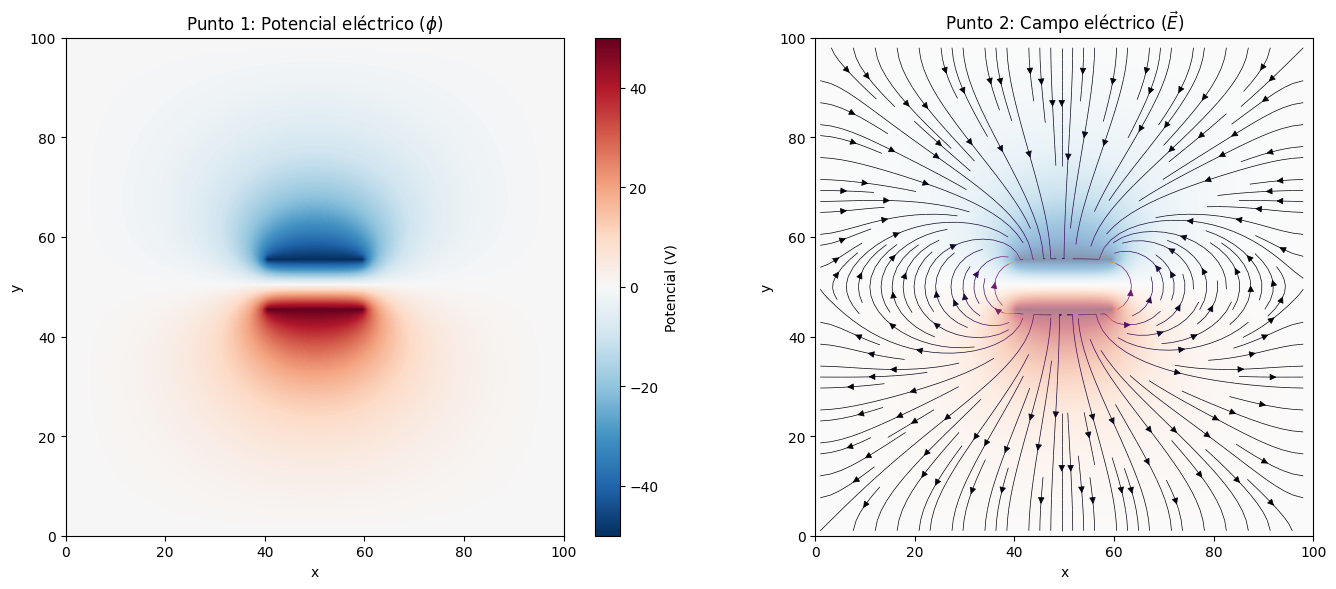

el maximo del valor del campo es = 13.33 V


In [7]:
# Ejercicio 3

# 1. Ecuacion de laplace y grafica potencial
Nx, Ny = 100, 100
V = np.zeros((Ny, Nx))

V0 = 50.0
d = 10  # Separación horizontal entre placas
l = 20  # Longitud vertical de las placas

# Coordenadas propuestas para las barras centradas
x_izq = int((Nx / 2) - (d / 2))
x_der = int((Nx / 2) + (d / 2))
y_inicio = int((Ny / 2) - (l / 2))
y_fin = int((Ny / 2) + (l / 2))

Niter = 1000
for iter in range(Niter):
    V_nuevo = V.copy()

    # Diferencias finitas para el potencial
    for i in range(1, Ny - 1):
        for j in range(1, Nx - 1):
            V_nuevo[i, j] = 0.25 * (V[i+1, j] + V[i-1, j] + V[i, j+1] + V[i, j-1])

    # Condiciones de frontera en las barras
    V_nuevo[y_inicio:y_fin, x_izq] = V0
    V_nuevo[y_inicio:y_fin, x_der] = -V0

    V = V_nuevo

# 2. calcula el campo electrico
U = V.copy()

# Diferencias finitas para el campo eléctrico
E = -np.stack([
    (U[2:, 1:-1] - U[0:-2, 1:-1]) / 2,
    (U[1:-1, 2:] - U[1:-1, 0:-2]) / 2,
], axis=-1)

Ex = E[..., 0]
Ey = E[..., 1]

x = np.arange(1, Nx-1)
y = np.arange(1, Ny-1)
X, Y = np.meshgrid(x, y, indexing='ij')

#Graficas para el potencial y el campo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica 1
im1 = ax1.imshow(U.T, origin='lower', cmap='RdBu_r', extent=[0, Nx, 0, Ny], interpolation="bilinear")
ax1.set_title(r'Punto 1: Potencial eléctrico ($\phi$)')
ax1.set_xlabel("x")
ax1.set_ylabel("y")
fig.colorbar(im1, ax=ax1, label='Potencial (V)')

# Gráfica 2
ax2.imshow(U.T, origin='lower', cmap='RdBu_r', extent=[0, Nx, 0, Ny], interpolation="bilinear", alpha=0.5)
magnitude = np.sqrt(Ex**2 + Ey**2)
ax2.streamplot(X.T, Y.T, Ex.T, Ey.T, color=magnitude.T, cmap='inferno', density=1.5, linewidth=0.5)


ax2.set_title(r'Punto 2: Campo eléctrico ($\vec{E}$)')
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()
print(f"el maximo del valor del campo es = {np.max(magnitude):.2f} V")